# Multi-Omics KEGG Pathway Analysis — Biological Interpretation

What it does:
1. Finds the features (CpG probes & RNA genes) that best separate the 6 cancer types (ANOVA)
2. Maps methylation probes to gene names using the Illumina 450K annotation
3. Runs **GSEA** (ranked) and **ORA** (threshold) KEGG enrichment for both omics layers
4. Compares pathways across methylation and RNA — identifies shared vs. layer-specific biology
5. Saves publication-ready figures and CSV tables

Improvements over v1:
- RNA-seq ANOVA + pathway analysis added (truly multi-omics)
- GSEA using full F-statistic ranking (no arbitrary top-N cutoff)
- Cross-omics pathway comparison
- Per-cancer-type heatmaps for both layers

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
!pip install -q anndata numpy pandas scipy matplotlib seaborn gseapy mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.9 MB/s eta 0:00:00


## 1. Configuration

In [3]:
SHARED_FOLDER_NAME = "multiomics-project"
from pathlib import Path

DRIVE_ROOT  = Path(f"/content/drive/MyDrive/{SHARED_FOLDER_NAME}")
RAW_DIR     = DRIVE_ROOT / "data/raw"
MANIFEST    = DRIVE_ROOT / "data/manifests/matched_samples.csv"
METH_H5AD   = DRIVE_ROOT / "data/processed/tcga_methylation.h5ad"
RNA_H5AD    = DRIVE_ROOT / "data/processed/tcga_rna_seq.h5ad"
RESULTS_DIR = DRIVE_ROOT / "results/kegg"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Parameters
N_TOP_PROBES = 500   # top discriminative CpG probes for ORA
N_TOP_GENES  = 500   # top discriminative RNA genes for ORA
GSEA_PERM    = 1000  # permutation number for GSEA

print('Methylation h5ad exists:', METH_H5AD.exists())
print('RNA h5ad exists        :', RNA_H5AD.exists())
print('Raw data folder exists :', RAW_DIR.exists())
print('Manifest exists        :', MANIFEST.exists())

Methylation h5ad exists: True
RNA h5ad exists        : True
Raw data folder exists : True
Manifest exists        : True


## 2. Load data

Loads both methylation and RNA-seq. If the methylation h5ad has zero values (known pipeline bug), rebuilds from raw files in memory.

In [4]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy import stats

# --- Load RNA-seq ---
print('Loading RNA-seq data...')
adata_rna = ad.read_h5ad(RNA_H5AD)
X_rna = adata_rna.X if isinstance(adata_rna.X, np.ndarray) else adata_rna.X.toarray()
rna_gene_ids = adata_rna.var.index.astype(str).tolist()
print(f'RNA-seq shape: {adata_rna.shape}')

# --- Load methylation ---
print('Loading methylation data...')
adata_meth = ad.read_h5ad(METH_H5AD)
X_meth = adata_meth.X if isinstance(adata_meth.X, np.ndarray) else adata_meth.X.toarray()
labels = adata_meth.obs['cancer_type'].values
probe_ids = adata_meth.var.index.astype(str).tolist()

# Recover real CpG IDs if feature names are numeric positions
if probe_ids and not probe_ids[0].startswith('cg'):
    probe_list_path = DRIVE_ROOT / 'data/processed/probe_ids_type3.csv'
    probe_table = pd.read_csv(probe_list_path)
    cpg_cols = [c for c in probe_table.columns if probe_table[c].astype(str).str.startswith('cg').mean() > 0.5]
    if not cpg_cols:
        raise ValueError(f'Could not find CpG probe column in {probe_list_path}')
    probe_lookup = probe_table[cpg_cols[0]].astype(str).str.strip().tolist()
    numeric_positions = pd.to_numeric(pd.Index(probe_ids), errors='coerce')
    if numeric_positions.isna().any() or int(numeric_positions.max()) >= len(probe_lookup):
        raise ValueError('Cannot map h5ad feature IDs to probe_ids_type3.csv')
    probe_ids = [probe_lookup[int(i)] for i in numeric_positions]
    print(f'Recovered CpG probe IDs from {probe_list_path.name}')

n_variable = int((np.nanvar(X_meth, axis=0) > 0).sum())
print(f'Methylation shape: {adata_meth.shape}')
print(f'Variable probes in h5ad: {n_variable}/{X_meth.shape[1]}')

# Rebuild methylation from raw files if h5ad is all zeros
if n_variable == 0:
    print('h5ad methylation values are constant. Rebuilding from raw files...')
    manifest = pd.read_csv(MANIFEST)
    data_list, label_list = [], []
    for _, row in manifest.iterrows():
        file_path = RAW_DIR / row['project'] / 'methylation' / row['meth_file_name']
        if not file_path.exists():
            continue
        sample_df = pd.read_csv(file_path, sep='\t', header=None, names=['probe', 'beta'])
        sample_df['probe'] = sample_df['probe'].astype(str).str.strip()
        sample_df['beta'] = pd.to_numeric(sample_df['beta'], errors='coerce')
        sample_df = sample_df.drop_duplicates('probe', keep='first').set_index('probe')
        data_list.append(sample_df.reindex(probe_ids)['beta'].to_numpy(dtype=np.float32))
        label_list.append(row['project'])
        if len(data_list) % 100 == 0:
            print(f'  Loaded {len(data_list)} files...')
    X_meth = np.nan_to_num(np.stack(data_list), nan=0.0)
    labels = np.array(label_list)
    print(f'Rebuilt methylation: {X_meth.shape}, variable probes: {int((np.nanvar(X_meth, axis=0) > 0).sum())}')

cancer_types = np.unique(labels)
print(f'\nCancer types: {dict(zip(*np.unique(labels, return_counts=True)))}')
print(f'Example CpG probes: {probe_ids[:3]}')
print(f'Example RNA genes: {rna_gene_ids[:3]}')

Loading RNA-seq data...
RNA-seq shape: (800, 60616)
Loading methylation data...
Methylation shape: (800, 49156)
Variable probes in h5ad: 47199/49156

Cancer types: {'TCGA-BRCA': np.int64(134), 'TCGA-COAD': np.int64(133), 'TCGA-KIRC': np.int64(133), 'TCGA-LIHC': np.int64(133), 'TCGA-LUAD': np.int64(134), 'TCGA-THCA': np.int64(133)}
Example CpG probes: ['cg00000109', 'cg00000292', 'cg00002033']
Example RNA genes: ['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419']


## 3. ANOVA — Find discriminative features in both omics layers

For each feature (CpG probe or RNA gene), compute an F-statistic testing whether it differs across the 6 cancer types. High F = strong cancer-type discriminator.

In [5]:
def run_anova(X, labels, feature_ids, layer_name):
    """Run one-way ANOVA for each feature across cancer types."""
    cancer_types = np.unique(labels)
    n_features = X.shape[1]
    f_stats = np.zeros(n_features)
    p_vals = np.ones(n_features)
    probe_var = np.nanvar(X, axis=0)
    variable_idx = np.where(probe_var > 0)[0]
    print(f'{layer_name}: running ANOVA on {len(variable_idx)}/{n_features} variable features...')

    for i in variable_idx:
        groups = [X[labels == ct, i] for ct in cancer_types]
        f_stats[i], p_vals[i] = stats.f_oneway(*groups)

    f_stats = np.nan_to_num(f_stats, nan=0.0)
    p_vals = np.nan_to_num(p_vals, nan=1.0)

    # Build results dataframe
    df = pd.DataFrame({
        'feature_id': feature_ids,
        'f_statistic': f_stats,
        'p_value': p_vals,
    })
    df = df.sort_values('f_statistic', ascending=False).reset_index(drop=True)
    df['rank'] = range(1, len(df) + 1)

    top_f = df['f_statistic'].iloc[0]
    print(f'  Top F-statistic: {top_f:.1f}')
    print(f'  Features with p < 0.05: {(df["p_value"] < 0.05).sum()}')
    return df

meth_anova = run_anova(X_meth, labels, probe_ids, 'Methylation')
rna_anova  = run_anova(X_rna, labels, rna_gene_ids, 'RNA-seq')

Methylation: running ANOVA on 47199/49156 variable features...
  Top F-statistic: 1654.0
  Features with p < 0.05: 46365
RNA-seq: running ANOVA on 57906/60616 variable features...
  Top F-statistic: 549.4
  Features with p < 0.05: 46753


## 4. Map methylation probes to genes

RNA-seq features are already gene symbols. Methylation probes need to be mapped via the Illumina 450K annotation.

In [6]:
import urllib.request

ANNOTATION_URL = "https://raw.githubusercontent.com/chrisamiller/450k-annotation/master/HumanMethylation450_15017482_v1-2_filtered.csv"
ANNOTATION_PATH = Path("/content/450k_annotation.csv")

print('Downloading Illumina 450K annotation...')
try:
    urllib.request.urlretrieve(ANNOTATION_URL, ANNOTATION_PATH)
    annot = pd.read_csv(ANNOTATION_PATH, low_memory=False)
except Exception as e:
    print(f'Direct download failed ({e}), trying alternative...')
    !wget -q -O /content/450k_annotation.csv.gz "https://zhouserver.research.chop.edu/InfiniumAnnotation/20180909/HM450/HM450.hg38.manifest.tsv.gz"
    annot = pd.read_csv('/content/450k_annotation.csv.gz', sep='\t', low_memory=False)

print(f'Annotation loaded: {annot.shape}')

# Find probe and gene columns
probe_candidates = ['IlmnID', 'Name', 'Probe_ID', 'probeID', 'probe_id', 'ID']
gene_candidates = [
    'UCSC_RefGene_Name', 'UCSC_REFGENE_NAME', 'UCSC_RefGene_Name.hg19',
    'gene', 'Gene', 'Gene_Name', 'gene_name', 'geneNames', 'genes', 'Symbol'
]

probe_col = next((c for c in probe_candidates if c in annot.columns), None)
if probe_col is None:
    cpg_like_cols = [c for c in annot.columns if annot[c].astype(str).str.startswith('cg').mean() > 0.5]
    probe_col = cpg_like_cols[0] if cpg_like_cols else annot.columns[0]

gene_col = next((c for c in gene_candidates if c in annot.columns), None)
if gene_col is None:
    gene_like_cols = [c for c in annot.columns if 'gene' in c.lower() and 'group' not in c.lower()]
    gene_col = gene_like_cols[0] if gene_like_cols else None
if gene_col is None:
    raise ValueError(f'Could not find gene annotation column. Columns: {list(annot.columns)}')

print(f'Using probe column: {probe_col}')
print(f'Using gene column : {gene_col}')

def clean_probe_id(value):
    return str(value).strip().split('.')[0]

annot_clean = annot[[probe_col, gene_col]].copy()
annot_clean.columns = ['probe_id', 'gene_name']
annot_clean['probe_id'] = annot_clean['probe_id'].map(clean_probe_id)
annot_clean['gene_name'] = annot_clean['gene_name'].astype(str).str.strip()
annot_clean = annot_clean[annot_clean['probe_id'].str.startswith('cg')]
annot_clean = annot_clean[~annot_clean['gene_name'].isin(['', 'nan', 'NA', 'N/A', '---'])]

# For probes mapping to multiple genes (semicolon-separated), explode into separate rows
# This preserves the probe-to-gene mapping for weighted analysis
annot_clean['gene_name'] = annot_clean['gene_name'].str.split(';')
annot_clean = annot_clean.explode('gene_name')
annot_clean['gene_name'] = annot_clean['gene_name'].str.strip()
annot_clean = annot_clean[annot_clean['gene_name'] != '']

# Build probe -> gene mapping (take first gene for simple ORA)
probe_to_gene = dict(zip(annot_clean['probe_id'], annot_clean['gene_name']))
# Also build gene -> max F-stat mapping for GSEA ranking
print(f'Probes with gene annotation: {len(probe_to_gene)}')

Direct download failed (HTTP Error 404: Not Found), trying alternative...
Annotation loaded: (485577, 57)
Using probe column: probeID
Using gene column : gene
Probes with gene annotation: 408435


## 5. Build gene-level rankings for GSEA

For GSEA, we need a ranked gene list. For methylation, we aggregate probe-level F-statistics to the gene level by taking the **maximum** F-statistic across all probes mapping to a gene. For RNA-seq, genes are already the feature level.

In [7]:
def build_gene_ranking_methylation(anova_df, probe_to_gene):
    """Aggregate probe F-statistics to gene level (max F per gene)."""
    gene_f = {}
    for _, row in anova_df.iterrows():
        pid = row['feature_id']
        gene = probe_to_gene.get(pid, None)
        if gene is None:
            continue
        if gene not in gene_f or row['f_statistic'] > gene_f[gene]:
            gene_f[gene] = row['f_statistic']

    ranking = pd.DataFrame([
        {'gene': g, 'f_statistic': f} for g, f in gene_f.items()
    ]).sort_values('f_statistic', ascending=False).reset_index(drop=True)
    return ranking

def build_gene_ranking_rna(anova_df):
    """RNA features are already genes — just rename columns."""
    ranking = anova_df[['feature_id', 'f_statistic']].copy()
    ranking.columns = ['gene', 'f_statistic']
    # Take max F per gene (in case of duplicate gene symbols)
    ranking = ranking.groupby('gene')['f_statistic'].max().reset_index()
    ranking = ranking.sort_values('f_statistic', ascending=False).reset_index(drop=True)
    return ranking

meth_gene_ranking = build_gene_ranking_methylation(meth_anova, probe_to_gene)
rna_gene_ranking  = build_gene_ranking_rna(rna_anova)

print(f'Methylation gene-level ranking: {len(meth_gene_ranking)} genes')
print(f'  Top genes: {meth_gene_ranking["gene"].head(10).tolist()}')
print(f'RNA-seq gene-level ranking: {len(rna_gene_ranking)} genes')
print(f'  Top genes: {rna_gene_ranking["gene"].head(10).tolist()}')

# Save rankings
meth_gene_ranking.to_csv(RESULTS_DIR / 'methylation_gene_f_ranking.csv', index=False)
rna_gene_ranking.to_csv(RESULTS_DIR / 'rna_gene_f_ranking.csv', index=False)

Methylation gene-level ranking: 16178 genes
  Top genes: ['PAX8', 'SERPIND1', 'F2', 'PAQR9-AS1', 'GRK6', 'ATG14', 'ITIH1', 'GPAM', 'RBP5', 'APOC4-APOC2']
RNA-seq gene-level ranking: 60616 genes
  Top genes: ['ENSG00000165409', 'ENSG00000088538', 'ENSG00000132321', 'ENSG00000084674', 'ENSG00000106927', 'ENSG00000158089', 'ENSG00000115718', 'ENSG00000140254', 'ENSG00000113722', 'ENSG00000102409']


## 6. GSEA — Ranked KEGG enrichment (both omics)

Uses the full F-statistic ranking — no arbitrary top-N cutoff. This is more powerful than ORA because it uses the entire ranked list.

In [12]:
import mygene

print("Converting Ensembl IDs to gene symbols...")

mg = mygene.MyGeneInfo()

query_results = mg.querymany(
    rna_gene_ranking['gene'].astype(str).tolist(),
    scopes='ensembl.gene',
    fields='symbol',
    species='human'
)

mapping = {
    q['query']: q['symbol']
    for q in query_results
    if 'symbol' in q
}

rna_gene_ranking_gsea = rna_gene_ranking.copy()

rna_gene_ranking_gsea['gene'] = (
    rna_gene_ranking_gsea['gene']
    .astype(str)
    .map(mapping)
)

rna_gene_ranking_gsea = (
    rna_gene_ranking_gsea
    .dropna(subset=['gene'])
)

# remove duplicated symbols
rna_gene_ranking_gsea = (
    rna_gene_ranking_gsea
    .sort_values('f_statistic', ascending=False)
    .drop_duplicates(subset='gene', keep='first')
)

print(f"Genes before mapping: {len(rna_gene_ranking):,}")
print(f"Genes after mapping:  {len(rna_gene_ranking_gsea):,}")

print("\nExample mapped genes:")
print(rna_gene_ranking_gsea.head())

INFO:biothings.client:querying 1-1000 ...


Converting Ensembl IDs to gene symbols...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 21001-22000 ...
INFO:biothings.client:querying

Genes before mapping: 60,616
Genes after mapping:  43,996

Example mapped genes:
    gene  f_statistic
0   TSHR   549.428147
1  DOCK3   518.534099
2  DRC11   500.106394
3   APOB   483.735002
4   AMBP   477.828161


In [13]:
import gseapy as gp

def run_gsea(ranking_df, layer_name):
    """Run GSEA with KEGG pathway database."""
    print(f'Running GSEA for {layer_name} ({len(ranking_df)} genes)...')
    rnk = ranking_df.set_index('gene')['f_statistic']
    rnk = rnk[~rnk.index.duplicated(keep='first')]  # remove any dupes
    rnk = rnk.sort_values(ascending=False)

    gs_res = gp.prerank(
        rnk=rnk,
        gene_sets='KEGG_2021_Human',
        outdir=None,
        permutation_num=GSEA_PERM,
        seed=42,
        min_size=5,
        max_size=500,
        verbose=False,
    )
    return gs_res.res2d.sort_values('NES', ascending=False)

meth_gsea = run_gsea(meth_gene_ranking, 'Methylation')
rna_gsea  = run_gsea(rna_gene_ranking_gsea, 'RNA-seq')

# Save GSEA results
meth_gsea.to_csv(RESULTS_DIR / 'methylation_gsea_kegg.csv')
rna_gsea.to_csv(RESULTS_DIR / 'rna_gsea_kegg.csv')

print(f'\nMethylation GSEA — significant pathways (FDR < 0.25):')
meth_gsea_sig = meth_gsea[meth_gsea['FDR q-val'] < 0.25]
for _, row in meth_gsea_sig.head(15).iterrows():
    term = row['Term'].replace('KEGG_', '').replace('_', ' ')
    print(f'  {term:<55} NES={row["NES"]:+.2f}  FDR={row["FDR q-val"]:.4f}')

print(f'\nRNA-seq GSEA — significant pathways (FDR < 0.25):')
rna_gsea_sig = rna_gsea[rna_gsea['FDR q-val'] < 0.25]
for _, row in rna_gsea_sig.head(15).iterrows():
    term = row['Term'].replace('KEGG_', '').replace('_', ' ')
    print(f'  {term:<55} NES={row["NES"]:+.2f}  FDR={row["FDR q-val"]:.4f}')

2026-06-22 15:06:04,792 [WARNING] Duplicated values found in preranked stats: 2.05% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA for Methylation (16178 genes)...


2026-06-22 15:06:42,053 [WARNING] Duplicated values found in preranked stats: 4.75% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA for RNA-seq (43996 genes)...

Methylation GSEA — significant pathways (FDR < 0.25):
  Complement and coagulation cascades                     NES=+1.60  FDR=0.0743
  One carbon pool by folate                               NES=+1.57  FDR=0.0649
  Glyoxylate and dicarboxylate metabolism                 NES=+1.49  FDR=0.1710
  Synthesis and degradation of ketone bodies              NES=+1.49  FDR=0.1464
  beta-Alanine metabolism                                 NES=+1.48  FDR=0.1296
  Glycine, serine and threonine metabolism                NES=+1.46  FDR=0.1329
  Thyroid cancer                                          NES=+1.44  FDR=0.1527
  Butanoate metabolism                                    NES=+1.36  FDR=0.2482
  Sulfur relay system                                     NES=-1.35  FDR=0.2393

RNA-seq GSEA — significant pathways (FDR < 0.25):
  Complement and coagulation cascades                     NES=+1.56  FDR=0.0070
  Maturity onset diabetes of the young              

## 7. ORA — Over-representation analysis (top-N threshold)

For comparison with the original analysis and for the simpler bar-chart visualization. Uses the top N genes by F-statistic.

In [22]:
def run_ora(gene_list, layer_name):
    """Run ORA with KEGG pathway database."""
    print(f'Running ORA for {layer_name} ({len(gene_list)} genes)...')
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets='KEGG_2021_Human',
        organism='human',
        outdir=None,
        cutoff=0.05,
    )
    return enr.results.sort_values('Adjusted P-value')

# Top N genes for ORA
meth_ora_genes = meth_gene_ranking.head(N_TOP_PROBES)['gene'].tolist()
rna_ora_genes  = rna_gene_ranking_gsea.head(N_TOP_GENES)['gene'].tolist()

meth_ora = run_ora(meth_ora_genes, 'Methylation')
rna_ora  = run_ora(rna_ora_genes, 'RNA-seq')

# Save ORA results
meth_ora.to_csv(RESULTS_DIR / 'methylation_ora_kegg.csv', index=False)
rna_ora.to_csv(RESULTS_DIR / 'rna_ora_kegg.csv', index=False)

print(f'\nMethylation ORA — top pathways:')
for _, row in meth_ora.head(10).iterrows():
    term = row['Term'].replace('KEGG_', '').replace('_', ' ')
    print(f'  {term:<55} padj={row["Adjusted P-value"]:.4f}')

print(f'\nRNA-seq ORA — top pathways:')
for _, row in rna_ora.head(10).iterrows():
    term = row['Term'].replace('KEGG_', '').replace('_', ' ')
    print(f'  {term:<55} padj={row["Adjusted P-value"]:.4f}')

Running ORA for Methylation (500 genes)...
Running ORA for RNA-seq (500 genes)...

Methylation ORA — top pathways:
  Complement and coagulation cascades                     padj=0.0000
  Thyroid cancer                                          padj=0.0378
  Parathyroid hormone synthesis, secretion and action     padj=0.1185
  TNF signaling pathway                                   padj=0.1185
  Hepatitis B                                             padj=0.1185
  Thyroid hormone synthesis                               padj=0.1185
  VEGF signaling pathway                                  padj=0.1318
  beta-Alanine metabolism                                 padj=0.2093
  Propanoate metabolism                                   padj=0.2857
  Pertussis                                               padj=0.2857

RNA-seq ORA — top pathways:
  Complement and coagulation cascades                     padj=0.0000
  Cholesterol metabolism                                  padj=0.0000
  Maturity onset

## 8. Cross-omics pathway comparison

Identify pathways enriched in both layers (shared biology) vs. layer-specific pathways.

In [15]:
def clean_term(term):
    return term.replace('KEGG_', '').replace('_', ' ')

# Use GSEA results (more robust than ORA)
# Get pathways with FDR < 0.25 from each layer
meth_sig = meth_gsea[meth_gsea['FDR q-val'] < 0.25].copy()
rna_sig  = rna_gsea[rna_gsea['FDR q-val'] < 0.25].copy()

meth_terms = set(meth_sig['Term'].tolist())
rna_terms  = set(rna_sig['Term'].tolist())
shared_terms = meth_terms & rna_terms
meth_only = meth_terms - rna_terms
rna_only  = rna_terms - meth_terms

print(f'Methylation significant pathways (GSEA FDR < 0.25): {len(meth_terms)}')
print(f'RNA-seq significant pathways (GSEA FDR < 0.25): {len(rna_terms)}')
print(f'Shared pathways: {len(shared_terms)}')
print(f'Methylation-only: {len(meth_only)}')
print(f'RNA-only: {len(rna_only)}')

print(f'\n--- Shared pathways (enriched in BOTH layers) ---')
for term in sorted(shared_terms):
    m_nes = meth_sig.loc[meth_sig['Term'] == term, 'NES'].values[0]
    r_nes = rna_sig.loc[rna_sig['Term'] == term, 'NES'].values[0]
    m_fdr = meth_sig.loc[meth_sig['Term'] == term, 'FDR q-val'].values[0]
    r_fdr = rna_sig.loc[rna_sig['Term'] == term, 'FDR q-val'].values[0]
    print(f'  {clean_term(term):<55} Meth NES={m_nes:+.2f}(FDR={m_fdr:.3f})  RNA NES={r_nes:+.2f}(FDR={r_fdr:.3f})')

print(f'\n--- Methylation-specific pathways ---')
for term in sorted(meth_only):
    nes = meth_sig.loc[meth_sig['Term'] == term, 'NES'].values[0]
    fdr = meth_sig.loc[meth_sig['Term'] == term, 'FDR q-val'].values[0]
    print(f'  {clean_term(term):<55} NES={nes:+.2f}  FDR={fdr:.3f}')

print(f'\n--- RNA-specific pathways ---')
for term in sorted(rna_only):
    nes = rna_sig.loc[rna_sig['Term'] == term, 'NES'].values[0]
    fdr = rna_sig.loc[rna_sig['Term'] == term, 'FDR q-val'].values[0]
    print(f'  {clean_term(term):<55} NES={nes:+.2f}  FDR={fdr:.3f}')

# Save comparison table
comparison_rows = []
for term in meth_terms | rna_terms:
    row = {'pathway': clean_term(term), 'term_raw': term}
    if term in meth_terms:
        row['meth_nes'] = float(meth_sig.loc[meth_sig['Term'] == term, 'NES'].values[0])
        row['meth_fdr'] = float(meth_sig.loc[meth_sig['Term'] == term, 'FDR q-val'].values[0])
    if term in rna_terms:
        row['rna_nes'] = float(rna_sig.loc[rna_sig['Term'] == term, 'NES'].values[0])
        row['rna_fdr'] = float(rna_sig.loc[rna_sig['Term'] == term, 'FDR q-val'].values[0])
    row['layer'] = 'shared' if term in shared_terms else ('methylation' if term in meth_only else 'rna')
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('layer')
comparison_df.to_csv(RESULTS_DIR / 'cross_omics_pathway_comparison.csv', index=False)
print(f'\nSaved cross-omics comparison table')

Methylation significant pathways (GSEA FDR < 0.25): 9
RNA-seq significant pathways (GSEA FDR < 0.25): 253
Shared pathways: 9
Methylation-only: 0
RNA-only: 244

--- Shared pathways (enriched in BOTH layers) ---
  Butanoate metabolism                                    Meth NES=+1.36(FDR=0.248)  RNA NES=+1.25(FDR=0.101)
  Complement and coagulation cascades                     Meth NES=+1.60(FDR=0.074)  RNA NES=+1.56(FDR=0.007)
  Glycine, serine and threonine metabolism                Meth NES=+1.46(FDR=0.133)  RNA NES=+1.36(FDR=0.096)
  Glyoxylate and dicarboxylate metabolism                 Meth NES=+1.49(FDR=0.171)  RNA NES=+1.21(FDR=0.092)
  One carbon pool by folate                               Meth NES=+1.57(FDR=0.065)  RNA NES=+1.31(FDR=0.117)
  Sulfur relay system                                     Meth NES=-1.35(FDR=0.239)  RNA NES=+1.20(FDR=0.096)
  Synthesis and degradation of ketone bodies              Meth NES=+1.49(FDR=0.146)  RNA NES=+1.32(FDR=0.128)
  Thyroid cancer    

## 9. Figures

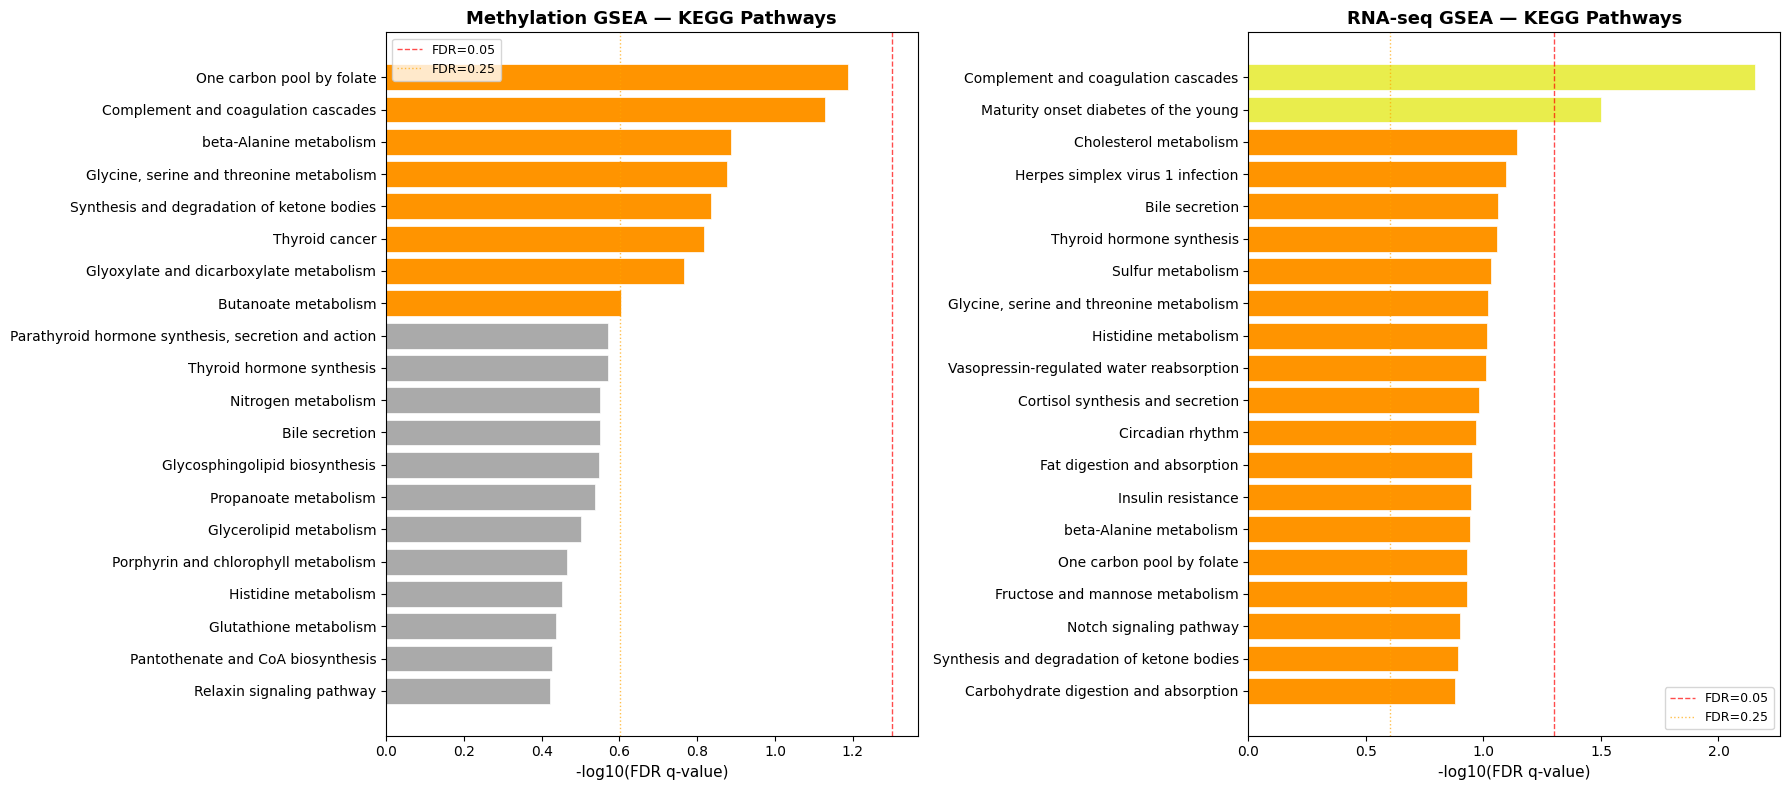

Saved: gsea_kegg_both_layers.png


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Figure 1: GSEA bar charts (both layers side by side) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, gsea_df, title in [
    (axes[0], meth_gsea, 'Methylation'),
    (axes[1], rna_gsea, 'RNA-seq'),
]:
    top20 = gsea_df.head(20).copy()
    top20['-log10(FDR)'] = -np.log10(top20['FDR q-val'].clip(1e-10))
    top20['Term_clean'] = top20['Term'].str.replace(r'^KEGG_', '', regex=True).str.replace('_', ' ')
    top20 = top20.sort_values('-log10(FDR)')

    colors = ['#E9ED4C' if fdr < 0.05 else '#FF9400' if fdr < 0.25 else '#AAAAAA'
              for fdr in top20['FDR q-val']]
    ax.barh(top20['Term_clean'], top20['-log10(FDR)'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=1, alpha=0.7, label='FDR=0.05')
    ax.axvline(x=-np.log10(0.25), color='orange', linestyle=':', linewidth=1, alpha=0.7, label='FDR=0.25')
    ax.set_xlabel('-log10(FDR q-value)', fontsize=11)
    ax.set_title(f'{title} GSEA — KEGG Pathways', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gsea_kegg_both_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gsea_kegg_both_layers.png')

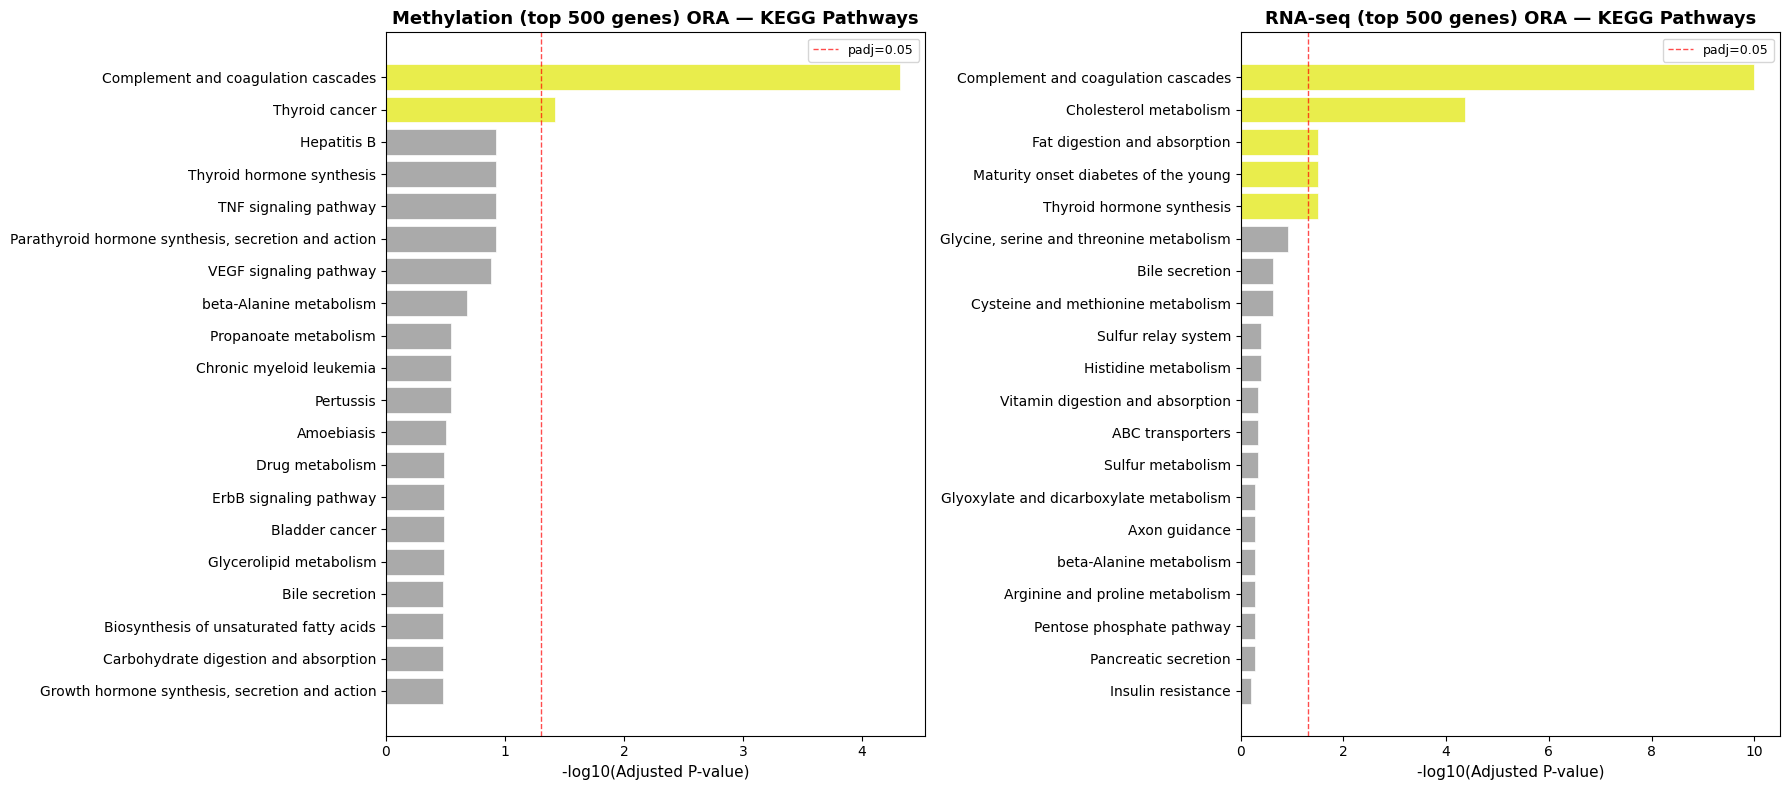

Saved: ora_kegg_both_layers.png


In [23]:
# --- Figure 2: ORA bar charts (both layers side by side) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, ora_df, title in [
    (axes[0], meth_ora, f'Methylation (top {N_TOP_PROBES} genes)'),
    (axes[1], rna_ora, f'RNA-seq (top {N_TOP_GENES} genes)'),
]:
    top20 = ora_df.head(20).copy()
    top20['-log10(padj)'] = -np.log10(top20['Adjusted P-value'].clip(1e-10))
    top20['Term_clean'] = top20['Term'].str.replace(r'^KEGG_', '', regex=True).str.replace('_', ' ')
    top20 = top20.sort_values('-log10(padj)')

    colors = ['#E9ED4C' if p < 0.05 else '#FF9400' if p < 0.1 else '#AAAAAA'
              for p in top20['Adjusted P-value']]
    ax.barh(top20['Term_clean'], top20['-log10(padj)'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=1, alpha=0.7, label='padj=0.05')
    ax.set_xlabel('-log10(Adjusted P-value)', fontsize=11)
    ax.set_title(f'{title} ORA — KEGG Pathways', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ora_kegg_both_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ora_kegg_both_layers.png')

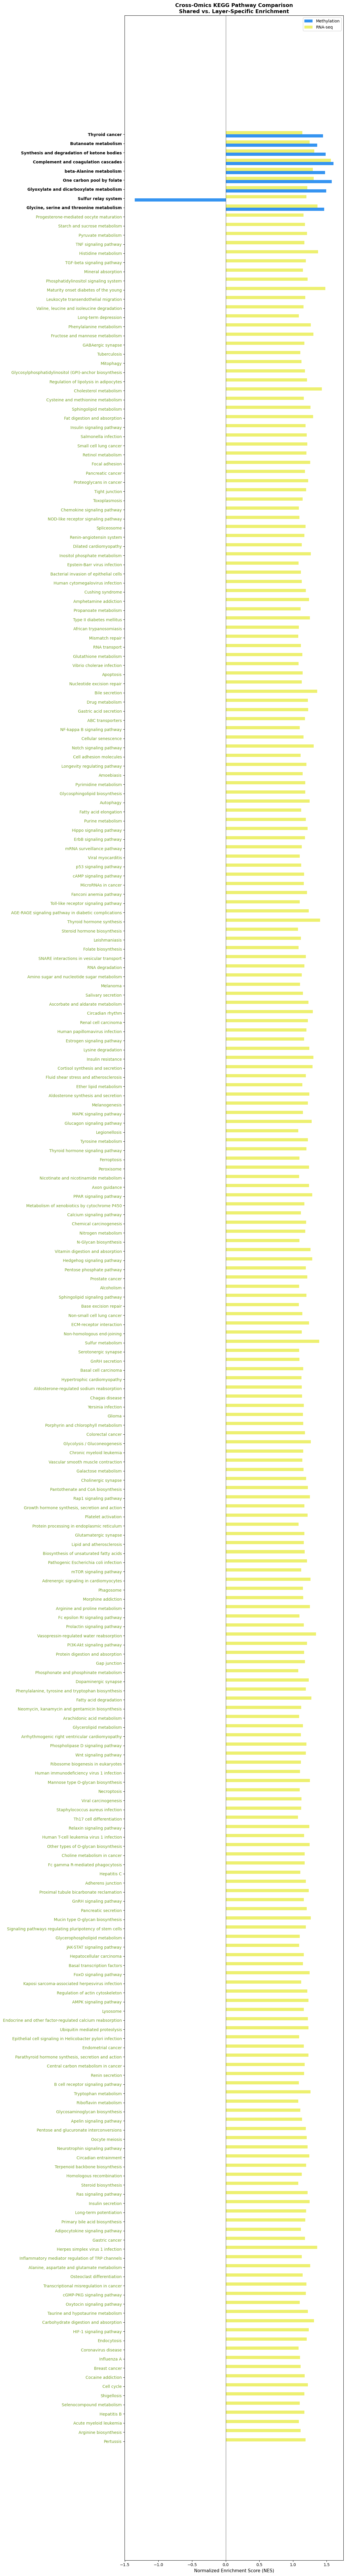

Saved: cross_omics_pathway_comparison.png


In [24]:
# --- Figure 3: Cross-omics pathway comparison dot plot ---
if len(comparison_df) > 0:
    fig, ax = plt.subplots(figsize=(12, max(6, len(comparison_df) * 0.35)))

    plot_df = comparison_df.copy()
    # Fill missing NES with 0 for plotting
    plot_df['meth_nes'] = plot_df['meth_nes'].fillna(0)
    plot_df['rna_nes'] = plot_df['rna_nes'].fillna(0)
    plot_df = plot_df.sort_values('layer')

    x = np.arange(len(plot_df))
    width = 0.35

    bars1 = ax.barh(x - width/2, plot_df['meth_nes'], width, label='Methylation', color='#0279EE', alpha=0.8)
    bars2 = ax.barh(x + width/2, plot_df['rna_nes'], width, label='RNA-seq', color='#E9ED4C', alpha=0.8)

    ax.set_yticks(x)
    ax.set_yticklabels(plot_df['pathway'])
    ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=11)
    ax.set_title('Cross-Omics KEGG Pathway Comparison\nShared vs. Layer-Specific Enrichment', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.axvline(x=0, color='black', linewidth=0.5)

    # Color y-tick labels by layer
    for i, label in enumerate(ax.get_yticklabels()):
        layer = plot_df.iloc[i]['layer']
        if layer == 'shared':
            label.set_fontweight('bold')
        elif layer == 'methylation':
            label.set_color('#0279EE')
        else:
            label.set_color('#75A025')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cross_omics_pathway_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: cross_omics_pathway_comparison.png')
else:
    print('No significant pathways to compare — adjust FDR threshold or check data')

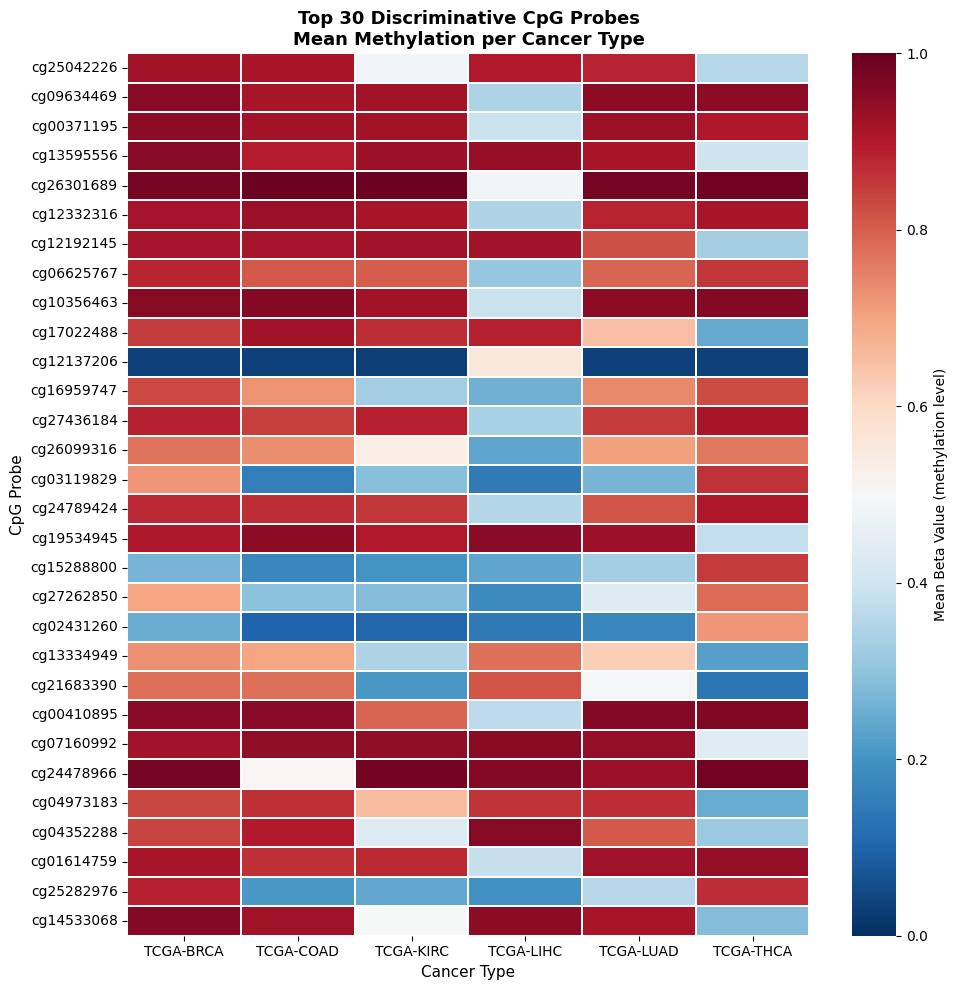

Saved: methylation_heatmap.png


In [19]:
# --- Figure 4: Methylation heatmap for top 30 discriminative probes ---
top30_idx = meth_anova.head(30).index.tolist()  # indices in original X_meth
# Need to map back to X_meth column positions
top30_feature_ids = meth_anova.head(30)['feature_id'].tolist()
top30_positions = [probe_ids.index(fid) for fid in top30_feature_ids]
X_top30 = X_meth[:, top30_positions]

heatmap_data = pd.DataFrame(
    {ct: X_top30[labels == ct].mean(axis=0) for ct in np.unique(labels)},
    index=[f'{p[:12]}...' if len(p) > 12 else p for p in top30_feature_ids]
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    heatmap_data,
    cmap='RdBu_r', center=0.5, vmin=0, vmax=1,
    ax=ax, linewidths=0.3,
    cbar_kws={'label': 'Mean Beta Value (methylation level)'}
)
ax.set_title('Top 30 Discriminative CpG Probes\nMean Methylation per Cancer Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cancer Type', fontsize=11)
ax.set_ylabel('CpG Probe', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'methylation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: methylation_heatmap.png')

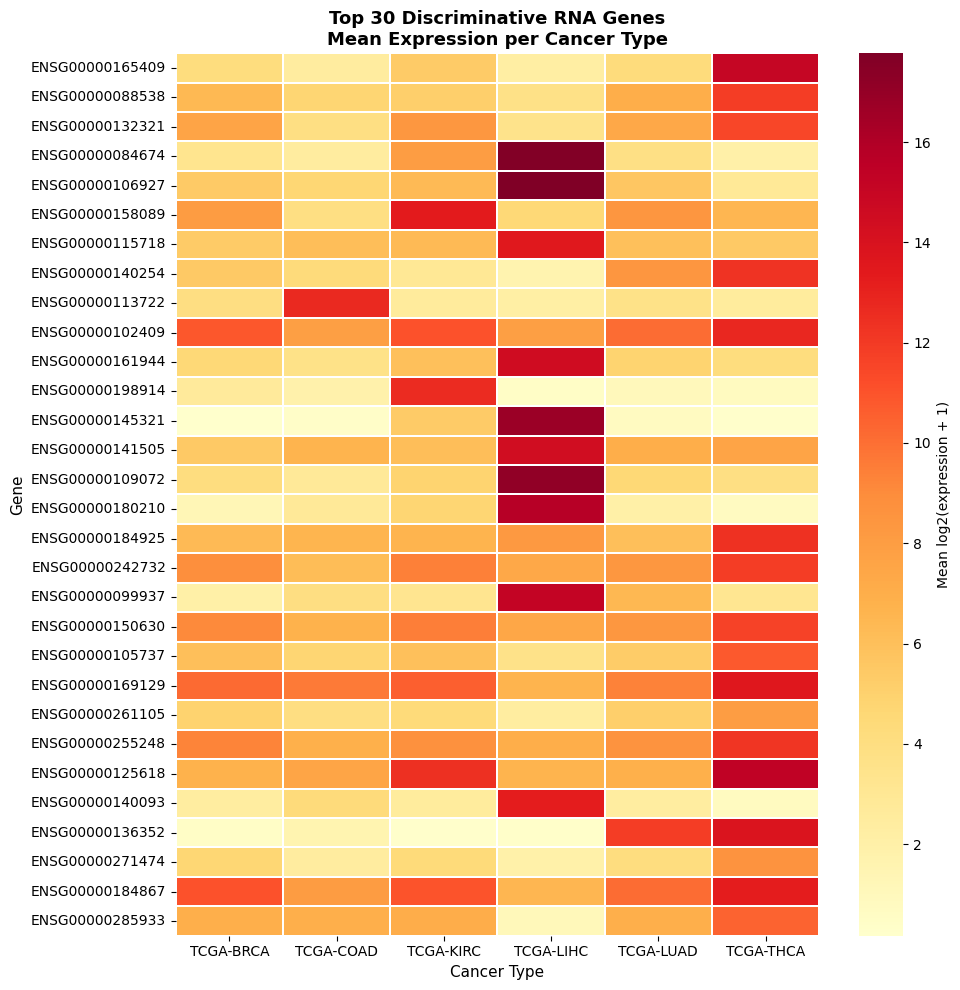

Saved: rna_heatmap.png


In [20]:
# --- Figure 5: RNA-seq heatmap for top 30 discriminative genes ---
top30_rna_ids = rna_anova.head(30)['feature_id'].tolist()
top30_rna_pos = [rna_gene_ids.index(gid) for gid in top30_rna_ids]
X_rna_top30 = X_rna[:, top30_rna_pos]

# Log-transform for visualization (RNA counts are often skewed)
X_rna_log = np.log2(X_rna_top30 + 1)

heatmap_rna = pd.DataFrame(
    {ct: X_rna_log[labels == ct].mean(axis=0) for ct in np.unique(labels)},
    index=top30_rna_ids
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    heatmap_rna,
    cmap='YlOrRd',
    ax=ax, linewidths=0.3,
    cbar_kws={'label': 'Mean log2(expression + 1)'}
)
ax.set_title('Top 30 Discriminative RNA Genes\nMean Expression per Cancer Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cancer Type', fontsize=11)
ax.set_ylabel('Gene', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'rna_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rna_heatmap.png')

## 10. Save top discriminative features tables

In [21]:
# Top methylation probes with gene annotation
top_probes = meth_anova.head(N_TOP_PROBES).copy()
top_probes['gene'] = top_probes['feature_id'].map(probe_to_gene)
top_probes.to_csv(RESULTS_DIR / 'top_discriminative_probes.csv', index=False)

# Top RNA genes
top_genes = rna_anova.head(N_TOP_GENES).copy()
top_genes.to_csv(RESULTS_DIR / 'top_discriminative_rna_genes.csv', index=False)

print(f'Saved top {N_TOP_PROBES} methylation probes with gene mapping')
print(f'Saved top {N_TOP_GENES} RNA genes')

print(f'\n=== All outputs saved to Drive/results/kegg/ ===')
print(f'  gsea_kegg_both_layers.png       — GSEA bar charts (both layers)')
print(f'  ora_kegg_both_layers.png         — ORA bar charts (both layers)')
print(f'  cross_omics_pathway_comparison.png — shared vs. layer-specific pathways')
print(f'  methylation_heatmap.png          — top 30 CpG probes heatmap')
print(f'  rna_heatmap.png                  — top 30 RNA genes heatmap')
print(f'  methylation_gsea_kegg.csv        — full methylation GSEA results')
print(f'  rna_gsea_kegg.csv                — full RNA GSEA results')
print(f'  methylation_ora_kegg.csv         — full methylation ORA results')
print(f'  rna_ora_kegg.csv                 — full RNA ORA results')
print(f'  cross_omics_pathway_comparison.csv — pathway comparison table')
print(f'  methylation_gene_f_ranking.csv   — gene-level F-statistic ranking (methylation)')
print(f'  rna_gene_f_ranking.csv           — gene-level F-statistic ranking (RNA)')
print(f'  top_discriminative_probes.csv    — top 500 probes with gene names')
print(f'  top_discriminative_rna_genes.csv — top 500 RNA genes')

Saved top 500 methylation probes with gene mapping
Saved top 500 RNA genes

=== All outputs saved to Drive/results/kegg/ ===
  gsea_kegg_both_layers.png       — GSEA bar charts (both layers)
  ora_kegg_both_layers.png         — ORA bar charts (both layers)
  cross_omics_pathway_comparison.png — shared vs. layer-specific pathways
  methylation_heatmap.png          — top 30 CpG probes heatmap
  rna_heatmap.png                  — top 30 RNA genes heatmap
  methylation_gsea_kegg.csv        — full methylation GSEA results
  rna_gsea_kegg.csv                — full RNA GSEA results
  methylation_ora_kegg.csv         — full methylation ORA results
  rna_ora_kegg.csv                 — full RNA ORA results
  cross_omics_pathway_comparison.csv — pathway comparison table
  methylation_gene_f_ranking.csv   — gene-level F-statistic ranking (methylation)
  rna_gene_f_ranking.csv           — gene-level F-statistic ranking (RNA)
  top_discriminative_probes.csv    — top 500 probes with gene names
  top_